In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [ ]:
df = pd.read_csv('IoTPond4.csv')
df.head()

,created_at,entry_id,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length(cm),Fish_Weight(g)
0,2021-06-19 00:00:22 CET,1738.0,24.9375,81.0,7.945,8.51990,10.68908,688.0,75,6.94,3.07
1,2021-06-19 00:00:42 CET,1739.0,25.0000,81.0,6.888,8.51990,11.21030,672.0,75,6.94,3.07
2,2021-06-19 00:01:02 CET,1740.0,25.0000,81.0,33.728,8.51536,11.21030,671.0,75,6.94,3.07
3,2021-06-19 00:01:23 CET,1741.0,24.9375,81.0,10.531,8.52444,10.68908,668.0,75,6.94,3.07
4,2021-06-19 00:02:48 CET,1745.0,24.9375,81.0,11.740,8.52444,11.21030,683.0,75,6.94,3.07


In [ ]:
print(df.isnull().sum())

created_at                  0
entry_id                   47
Temperature(C)             47
Turbidity(NTU)             47
Dissolved Oxygen(g/ml)     47
PH                         47
Ammonia(g/ml)             102
Nitrate(g/ml)              47
Population                  0
Fish_Length(cm)             0
Fish_Weight(g)              0
dtype: int64


In [ ]:
df['Ammonia(g/ml)'].fillna(df['Ammonia(g/ml)'].mean(), inplace=True)
df['Turbidity(NTU)'].fillna(df['Turbidity(NTU)'].mean(), inplace=True)
df['Temperature(C)'].fillna(df['Temperature(C)'].mean(), inplace=True)
df['Dissolved Oxygen(g/ml)'].fillna(df['Dissolved Oxygen(g/ml)'].mean(), inplace=True)
df['PH'].fillna(df['PH'].mean(), inplace=True)
df['Nitrate(g/ml)'].fillna(df['Nitrate(g/ml)'].mean(), inplace=True)

In [ ]:
df.drop(columns=['entry_id','Population'],axis=1,inplace=True)

In [ ]:
print(df.isnull().sum())

created_at                0
Temperature(C)            0
Turbidity(NTU)            0
Dissolved Oxygen(g/ml)    0
PH                        0
Ammonia(g/ml)             0
Nitrate(g/ml)             0
Fish_Length(cm)           0
Fish_Weight(g)            0
dtype: int64


In [ ]:
df.describe()

,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Weight(g)
count,89844.000000,89844.000000,89844.000000,89844.000000,89844.00000,89844.000000,89844.000000
mean,24.778295,96.476040,8.046123,7.734694,inf,1227.156219,70.603810
std,0.805949,6.302942,8.267317,0.297998,NaN,587.118489,58.409334
min,-127.000000,80.000000,0.007000,-0.990280,0.00001,215.000000,3.070000
25%,24.375000,96.000000,3.123000,7.557530,0.00026,516.000000,16.320000
50%,24.750000,100.000000,5.528000,7.625620,62.40035,1422.000000,58.480000
75%,25.125000,100.000000,9.179000,7.825360,567.43127,1760.000000,109.520000
max,26.625000,100.000000,41.118000,15.451660,inf,3455.000000,826.000000


In [ ]:
df.columns

Index(['created_at', 'Temperature(C)', 'Turbidity(NTU)',
       'Dissolved Oxygen(g/ml)', 'PH', 'Ammonia(g/ml)', 'Nitrate(g/ml)',
       'Fish_Length(cm)', 'Fish_Weight(g)'],
      dtype='object')

In [ ]:
df.shape

(89844, 9)

In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'], infer_datetime_format=True, utc=True)

In [ ]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [ ]:
df.head()

,created_at,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Length(cm),Fish_Weight(g),Date,month,year,hour,minutes,seconds
0,2021-06-19 00:00:22+00:00,24.9375,81.0,7.945,8.51990,10.68908,688.0,6.94,3.07,19,6,2021,0,0,22
1,2021-06-19 00:00:42+00:00,25.0000,81.0,6.888,8.51990,11.21030,672.0,6.94,3.07,19,6,2021,0,0,42
2,2021-06-19 00:01:02+00:00,25.0000,81.0,33.728,8.51536,11.21030,671.0,6.94,3.07,19,6,2021,0,1,2
3,2021-06-19 00:01:23+00:00,24.9375,81.0,10.531,8.52444,10.68908,668.0,6.94,3.07,19,6,2021,0,1,23
4,2021-06-19 00:02:48+00:00,24.9375,81.0,11.740,8.52444,11.21030,683.0,6.94,3.07,19,6,2021,0,2,48


In [ ]:
df.drop(["created_at"], axis = 1, inplace = True)

In [ ]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [ ]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [ ]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [ ]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [ ]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [ ]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [ ]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [ ]:
for i in range(len(df)):
    if df.loc[i, "Temperature(C)"] < 20 or df.loc[i, "Temperature(C)"] > 30:
        df.loc[i, "Temperature(C)"] = df.loc[i-1, "Temperature(C)"]

In [ ]:
df.at[0,'PH']=8.5

In [ ]:
for i in range(1,len(df)):
    if df.loc[i, "PH"] < 6 or df.loc[i, "PH"] > 8.5:
        df.loc[i, "PH"] = df.loc[i-1,'PH']

In [ ]:
for i in range(1,len(df)):
    if df.loc[i, "Dissolved Oxygen(g/ml)"] < 5 or df.loc[i, "Dissolved Oxygen(g/ml)"] > 20:
        df.loc[i, "Dissolved Oxygen(g/ml)"] = df.loc[i-1, "Dissolved Oxygen(g/ml)"]

In [ ]:
df["Ammonia(g/ml)"] = np.log(df["Ammonia(g/ml)"]) / 10.0
df["Ammonia(g/ml)"] = df["Ammonia(g/ml)"].abs()


In [ ]:
df["Nitrate(g/ml)"] = df["Nitrate(g/ml)"].apply(np.sqrt)

In [ ]:
df.describe()

,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Weight(g),Date,month,year,hour,minutes,seconds
count,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000,89844.000000
mean,24.779971,96.476040,8.545578,7.733856,0.709639,33.825973,70.603810,17.132563,7.161502,2021.000033,11.562174,29.452974,29.428487
std,0.627023,6.302942,3.449382,0.263634,0.347969,9.108275,58.409334,9.110462,0.748990,0.005778,6.941395,17.366679,17.302732
min,23.250000,80.000000,5.003000,7.094500,0.000103,14.662878,3.070000,1.000000,1.000000,2021.000000,0.000000,0.000000,0.000000
25%,24.375000,96.000000,5.933000,7.557530,0.467404,22.715633,16.320000,9.000000,7.000000,2021.000000,5.000000,14.000000,14.000000
50%,24.750000,100.000000,7.387000,7.625620,0.670074,37.709415,58.480000,19.000000,7.000000,2021.000000,12.000000,29.000000,29.000000
75%,25.125000,100.000000,10.092000,7.825360,0.921034,41.952354,109.520000,25.000000,8.000000,2021.000000,18.000000,45.000000,44.000000
max,26.625000,100.000000,19.998000,8.500000,2.678005,58.779248,826.000000,31.000000,12.000000,2022.000000,23.000000,59.000000,59.000000


In [ ]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

In [ ]:
df.head()

,Date,month,year,hour,minutes,seconds,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Length(cm),Fish_Weight(g)
0,19,6,2021,0,0,22,24.9375,81.0,7.945,8.5,0.236922,26.229754,6.94,3.07
1,19,6,2021,0,0,42,25.0000,81.0,6.888,8.5,0.241683,25.922963,6.94,3.07
2,19,6,2021,0,1,2,25.0000,81.0,6.888,8.5,0.241683,25.903668,6.94,3.07
3,19,6,2021,0,1,23,24.9375,81.0,10.531,8.5,0.236922,25.845696,6.94,3.07
4,19,6,2021,0,2,48,24.9375,81.0,11.740,8.5,0.241683,26.134269,6.94,3.07


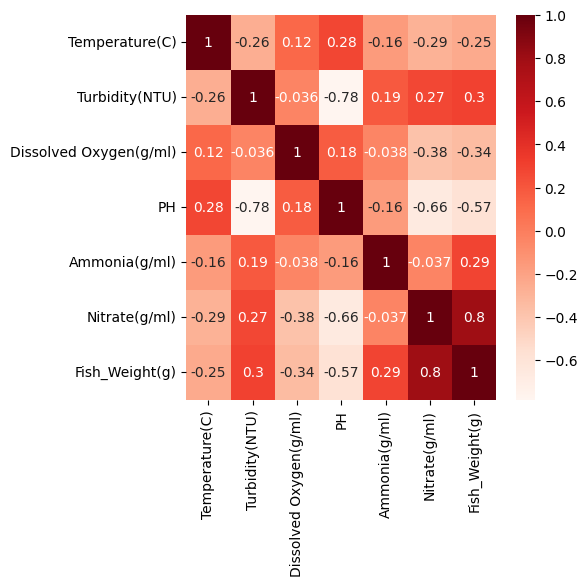

In [ ]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [ ]:
df.to_csv('pp4.csv', index=False)